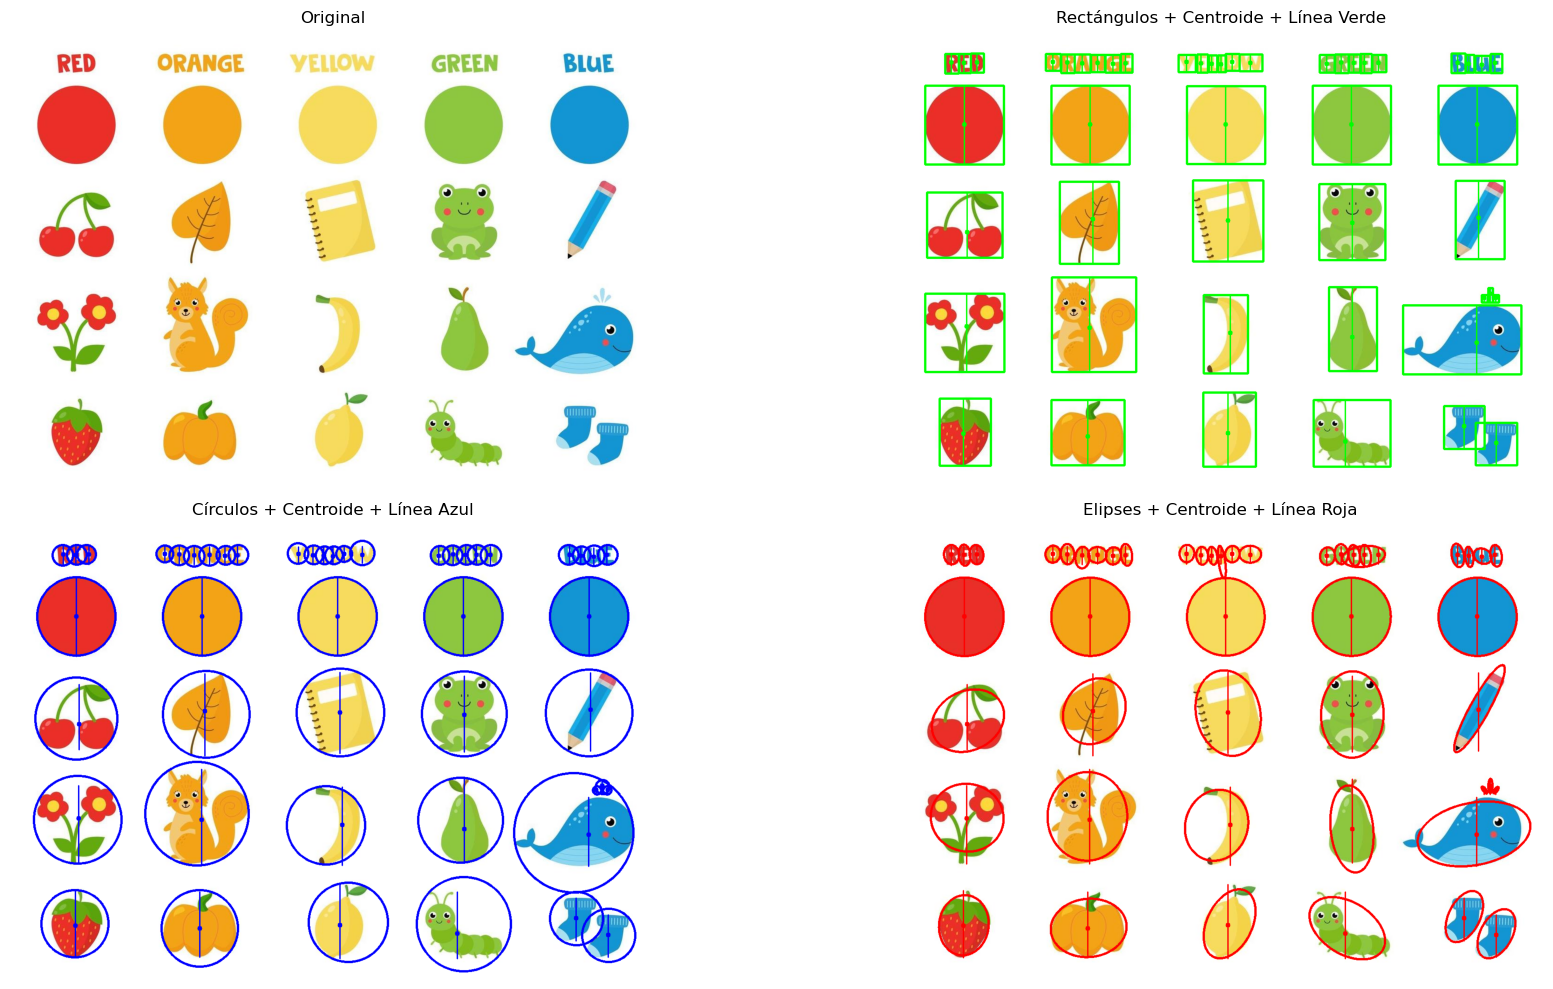

Contorno 1: Perímetro = 8.51 cm, Área = 136.18 cm^2
Contorno 2: Perímetro = 8.53 cm, Área = 135.96 cm^2
Contorno 3: Perímetro = 19.21 cm, Área = 249.46 cm^2
Contorno 4: Perímetro = 15.34 cm, Área = 392.15 cm^2
Contorno 5: Perímetro = 11.75 cm, Área = 278.13 cm^2
Contorno 6: Perímetro = 14.10 cm, Área = 271.25 cm^2
Contorno 7: Perímetro = 19.61 cm, Área = 561.37 cm^2
Contorno 8: Perímetro = 1.18 cm, Área = 2.09 cm^2
Contorno 9: Perímetro = 1.15 cm, Área = 2.20 cm^2
Contorno 10: Perímetro = 13.80 cm, Área = 189.60 cm^2
Contorno 11: Perímetro = 27.66 cm, Área = 299.14 cm^2
Contorno 12: Perímetro = 1.87 cm, Área = 4.89 cm^2
Contorno 13: Perímetro = 15.03 cm, Área = 294.76 cm^2
Contorno 14: Perímetro = 28.35 cm, Área = 582.67 cm^2
Contorno 15: Perímetro = 25.25 cm, Área = 285.54 cm^2
Contorno 16: Perímetro = 17.39 cm, Área = 475.56 cm^2
Contorno 17: Perímetro = 15.32 cm, Área = 336.18 cm^2
Contorno 18: Perímetro = 11.55 cm, Área = 163.96 cm^2
Contorno 19: Perímetro = 16.03 cm, Área = 486.71

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('colores.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
bin = cv2.threshold(gray, 225, 255, cv2.THRESH_BINARY_INV)[1]

contorno, jerarquía = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_rect = image.copy()
img_circles = image.copy()
img_ellipses = image.copy()

perimetros = []
areas = []

for i, cont in enumerate(contorno):
    M = cv2.moments(cont)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0

    area = cv2.contourArea(cont)
    perimetro = cv2.arcLength(cont, True)
    areas.append(area)
    perimetros.append(perimetro)

    x, y, w, h = cv2.boundingRect(cont)

    cv2.rectangle(img_rect, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.circle(img_rect, (cx, cy), 5, (0, 255, 0), -1)
    cv2.line(img_rect, (cx, y), (cx, y + h), (0, 255, 0), 2)

    (x_circ, y_circ), radius = cv2.minEnclosingCircle(cont)
    center = (int(x_circ), int(y_circ))
    radius = int(radius)
    cv2.circle(img_circles, center, radius, (255, 0, 0), 3)
    cv2.circle(img_circles, (cx, cy), 5, (255, 0, 0), -1)
    cv2.line(img_circles, (cx, y), (cx, y + h), (255, 0, 0), 2)

    if len(cont) >= 5:
        ellipse = cv2.fitEllipse(cont)
        cv2.ellipse(img_ellipses, ellipse, (0, 0, 255), 3)
        cv2.circle(img_ellipses, (cx, cy), 5, (0, 0, 255), -1)
        cv2.line(img_ellipses, (cx, y), (cx, y + h), (0, 0, 255), 2)

plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(222)
plt.imshow(cv2.cvtColor(img_rect, cv2.COLOR_BGR2RGB))
plt.title('Rectángulos + Centroide + Línea Verde')
plt.axis('off')

plt.subplot(223)
plt.imshow(cv2.cvtColor(img_circles, cv2.COLOR_BGR2RGB))
plt.title('Círculos + Centroide + Línea Azul')
plt.axis('off')

plt.subplot(224)
plt.imshow(cv2.cvtColor(img_ellipses, cv2.COLOR_BGR2RGB))
plt.title('Elipses + Centroide + Línea Roja')
plt.axis('off')

plt.tight_layout()
plt.show()

for i, (perimetro, area) in enumerate(zip(perimetros, areas)):
    print(f"Contorno {i + 1}: Perímetro = {perimetro/37.795276:.2f} cm, Área = {area/37.795276:.2f} cm^2")


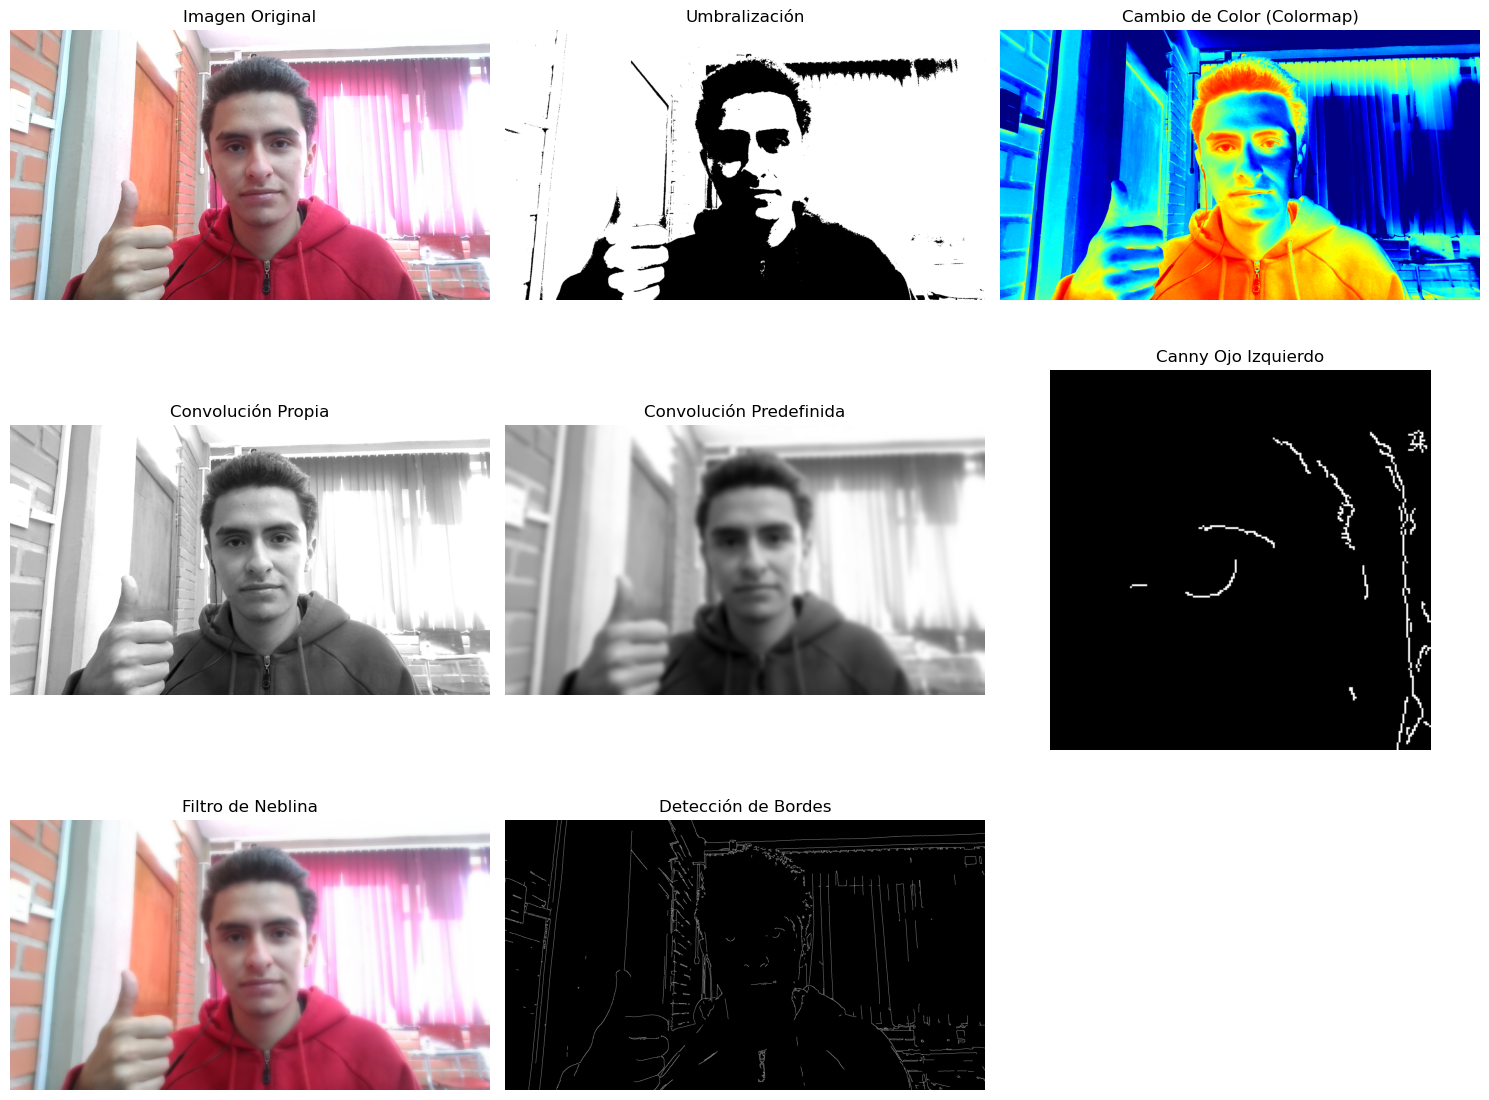

In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('foto.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

_, umbral = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY)

color_mapa = cv2.applyColorMap(gris, cv2.COLORMAP_JET)

kernel_propio = np.array([[1, 2, 1],
                          [1, 2, 1],
                          [1, 1, 1]], dtype=np.float32) / 10
convolucion1 = cv2.filter2D(gris, -1, kernel_propio)

convolucion2 = cv2.GaussianBlur(gris, (55, 55), 0)

alto, ancho = gris.shape
ojo_izq = gris[350:550, 1000:1200]
canny_ojo = cv2.Canny(ojo_izq, 100, 200)

blur = cv2.GaussianBlur(imagen, (41, 41), 0)
neblina = ((imagen * 0.3) + (blur * 0.7)).astype(np.uint8)

bordes = cv2.Canny(gris, 100, 200)

plt.figure(figsize=(15, 12))

plt.subplot(331)
plt.imshow(imagen_rgb)
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(332)
plt.imshow(umbral, cmap='gray')
plt.title("Umbralización")
plt.axis('off')

plt.subplot(333)
plt.imshow(color_mapa)
plt.title("Cambio de Color (Colormap)")
plt.axis('off')

plt.subplot(334)
plt.imshow(convolucion1, cmap='gray')
plt.title("Convolución Propia")
plt.axis('off')

plt.subplot(335)
plt.imshow(convolucion2, cmap='gray')
plt.title("Convolución Predefinida")
plt.axis('off')

plt.subplot(336)
plt.imshow(canny_ojo, cmap='gray')
plt.title("Canny Ojo Izquierdo")
plt.axis('off')

plt.subplot(337)
plt.imshow(cv2.cvtColor(neblina, cv2.COLOR_BGR2RGB))
plt.title("Filtro de Neblina")
plt.axis('off')

plt.subplot(338)
plt.imshow(bordes, cmap='gray')
plt.title("Detección de Bordes")
plt.axis('off')

plt.tight_layout()
plt.show()


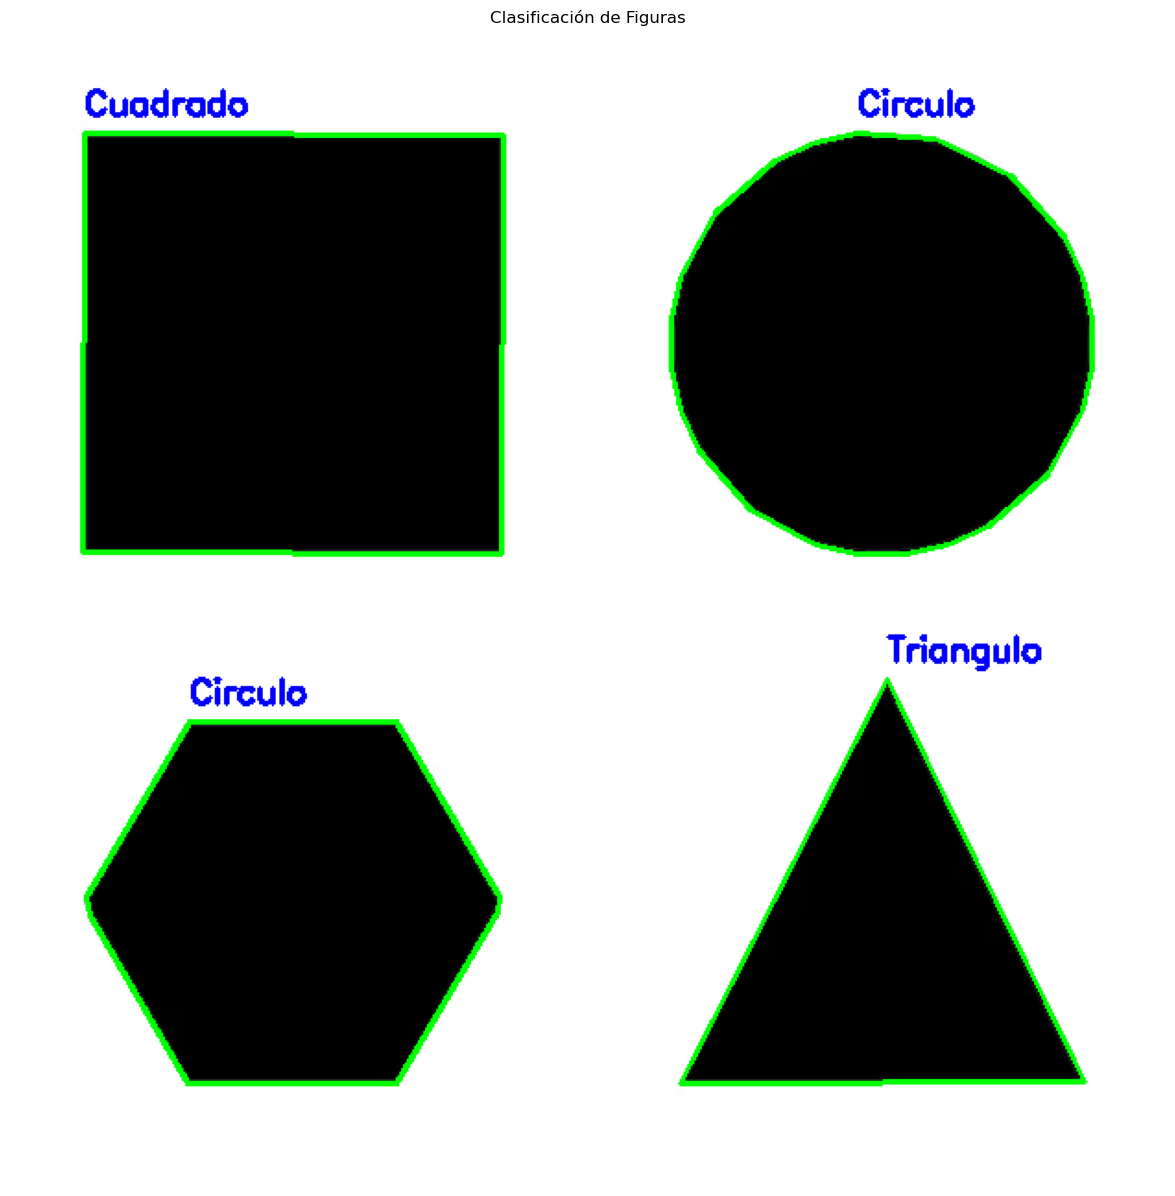

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('formas.avif')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
bin = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY_INV)[1]
contornos = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

for cnt in contornos:
    epsilon = 0.003 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    momentos = cv2.moments(cnt)
    huMomentos = cv2.HuMoments(momentos)
    forma = "Indefinido"
    vertices = len(approx)
    if vertices == 3:
        forma = "Triangulo"
    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w)/h
        forma = "Cuadrado" if 0.95 <= aspect_ratio <= 1.05 else "Rectangulo"
    elif vertices > 5:
        forma = "Circulo"
    cv2.drawContours(img, [approx], -1, (0, 255, 0), 2)
    x, y = approx.ravel()[0], approx.ravel()[1]
    cv2.putText(img, forma, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Clasificación de Figuras")
plt.show()